In [ ]:
#Очистка текста
import pandas as pd
import re
import os

possible_names = ['opensentimentcorpus-final-by-majority.csv', 'opensentimentcorpus-final-by-majority']
df = None
for name in possible_names:
    if os.path.exists(name):
        df = pd.read_csv(name)
        print(f"Загружен: {name}, строк: {len(df)}")
        break
if df is None:
    print("Файл не найден. Создаю демо-датасет.")
    df = pd.DataFrame({
        'Sentence': [
            "Мне всё просто СУПЕР!!! Рекомендую всем",
            "Отличный продукт, очень доволен покупкой",
            "Ужасное качество товара, не советую никому"
        ]
    })

df_work = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё ]', '', text)
    text = ' '.join(text.split())
    return text

df_work['clean_text'] = df_work['Sentence'].apply(clean_text)

print("=== ПРИМЕРЫ ДО ОЧИСТКИ ===")
for i in range(min(3, len(df_work))):
    print(f"{i+1}. {df_work['Sentence'].iloc[i]}")
print("\n=== ПРИМЕРЫ ПОСЛЕ ОЧИСТКИ ===")
for i in range(min(3, len(df_work))):
    print(f"{i+1}. {df_work['clean_text'].iloc[i]}")

Загружен: opensentimentcorpus-final-by-majority.csv, строк: 5961
=== ПРИМЕРЫ ДО ОЧИСТКИ ===
1. Не будущее, а то, что прожили.
2. На самом деле все меньше удовлетворения приносят те наборы благ, где их совокупное потребление не приводит к кумулятивному эффекту.
3. Несмотря на довольно тёплые отношения между республиками, Вильнюс, будучи председателем Организации по безопасности и сотрудничеству в Европе, признал выборы в Белоруссии не соответствующими демократическим требованиям.

=== ПРИМЕРЫ ПОСЛЕ ОЧИСТКИ ===
1. не будущее а то что прожили
2. на самом деле все меньше удовлетворения приносят те наборы благ где их совокупное потребление не приводит к кумулятивному эффекту
3. несмотря на довольно тёплые отношения между республиками вильнюс будучи председателем организации по безопасности и сотрудничеству в европе признал выборы в белоруссии не соответствующими демократическим требованиям


In [ ]:
#Лемматизация текста
!pip install pymorphy3 -q

import pandas as pd
import re
import os
import pymorphy3

possible_names = ['opensentimentcorpus-final-by-majority.csv', 'opensentimentcorpus-final-by-majority']
df = None
for name in possible_names:
    if os.path.exists(name):
        df = pd.read_csv(name)
        print(f"Загружен: {name}, строк: {len(df)}")
        break
if df is None:
    print("Файл не найден. Создаю демо-датасет.")
    df = pd.DataFrame({
        'Sentence': [
            "Мне всё просто СУПЕР!!! Рекомендую всем",
            "Отличный продукт, очень доволен покупкой"
        ]
    })

df_work = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё ]', '', text)
    text = ' '.join(text.split())
    return text

df_work['clean_text'] = df_work['Sentence'].apply(clean_text)

morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    words = text.split()
    lemmas = []
    for w in words:
        parsed = morph.parse(w)[0]
        lemmas.append(parsed.normal_form)
    return ' '.join(lemmas)

df_work['lemmas'] = df_work['clean_text'].apply(lemmatize_text)

print("=== ДО ЛЕММАТИЗАЦИИ (очищенный текст) ===")
for i in range(min(2, len(df_work))):
    print(f"{i+1}. {df_work['clean_text'].iloc[i]}")
print("\n=== ПОСЛЕ ЛЕММАТИЗАЦИИ ===")
for i in range(min(2, len(df_work))):
    print(f"{i+1}. {df_work['lemmas'].iloc[i]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.8 MB/s eta 0:00:00
Загружен: opensentimentcorpus-final-by-majority.csv, строк: 5961
=== ДО ЛЕММАТИЗАЦИИ (очищенный текст) ===
1. не будущее а то что прожили
2. на самом деле все меньше удовлетворения приносят те наборы благ где их совокупное потребление не приводит к кумулятивному эффекту

=== ПОСЛЕ ЛЕММАТИЗАЦИИ ===
1. не будущее а то что прожить
2. на сам дело всё маленький удовлетворение приносить тот набор благо где они совокупный потребление не приводить к кумулятивный эффект


Загружен: opensentimentcorpus-final-by-majority.csv, строк: 5961
ТОП-10 САМЫХ ЧАСТЫХ СЛОВ (ЛЕММЫ):
в: 3768
и: 3222
на: 1665
не: 1532
что: 1294
с: 1136
быть: 1020
это: 790
по: 683
он: 672


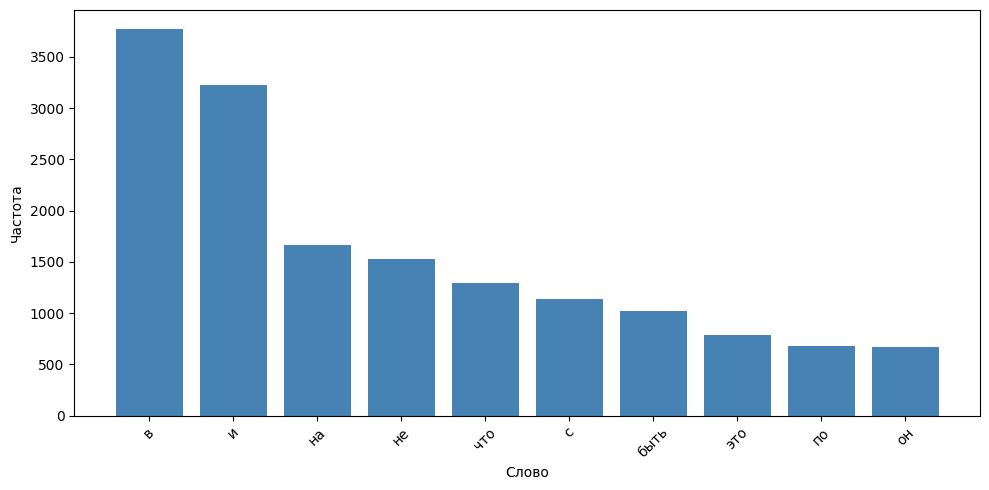

In [ ]:
#Частота слов
!pip install pymorphy3 wordcloud -q

import pandas as pd
import re
import os
import pymorphy3
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

possible_names = ['opensentimentcorpus-final-by-majority.csv', 'opensentimentcorpus-final-by-majority']
df = None
for name in possible_names:
    if os.path.exists(name):
        df = pd.read_csv(name)
        print(f"Загружен: {name}, строк: {len(df)}")
        break
if df is None:
    print("Файл не найден. Создаю демо-датасет.")
    df = pd.DataFrame({
        'Sentence': [
            "хороший товар отличный товар",
            "плохой товар ужасный товар",
            "нейтральный отзыв"
        ]
    })

df_work = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё ]', '', text)
    text = ' '.join(text.split())
    return text

df_work['clean_text'] = df_work['Sentence'].apply(clean_text)

morph = pymorphy3.MorphAnalyzer()
def lemmatize_text(text):
    words = text.split()
    lemmas = []
    for w in words:
        parsed = morph.parse(w)[0]
        lemmas.append(parsed.normal_form)
    return ' '.join(lemmas)

df_work['lemmas'] = df_work['clean_text'].apply(lemmatize_text)

all_words = ' '.join(df_work['lemmas']).split()
word_counts = Counter(all_words)
top10 = word_counts.most_common(10)

print("ТОП-10 САМЫХ ЧАСТЫХ СЛОВ (ЛЕММЫ):")
for word, cnt in top10:
    print(f"{word}: {cnt}")

plt.figure(figsize=(10, 5))
words, counts = zip(*top10)
plt.bar(words, counts, color='steelblue')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Loaded opensentimentcorpus-final-by-majority.csv, rows: 5961
TOP-10 AFTER STOPWORDS REMOVAL:
это: 790
который: 610
год: 558
свой: 384
всё: 355
весь: 330
мочь: 287
человек: 251
время: 240
россия: 224


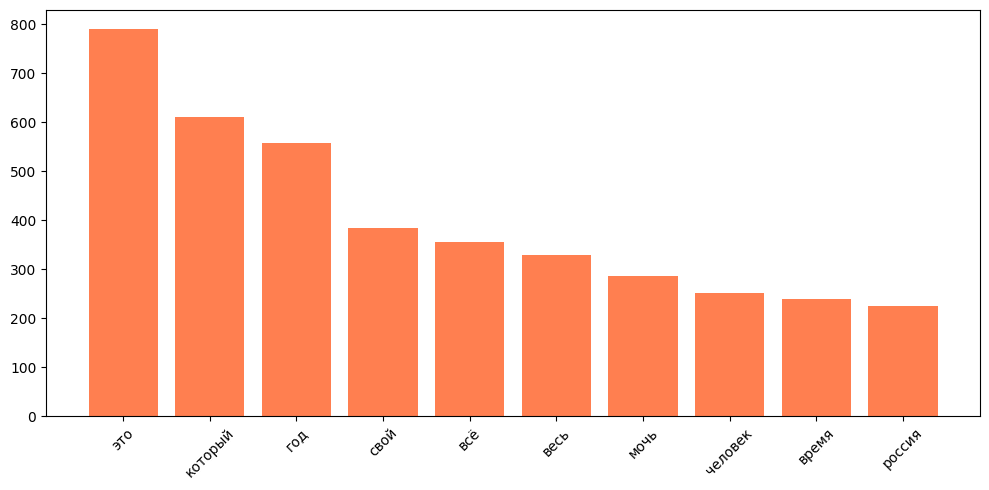

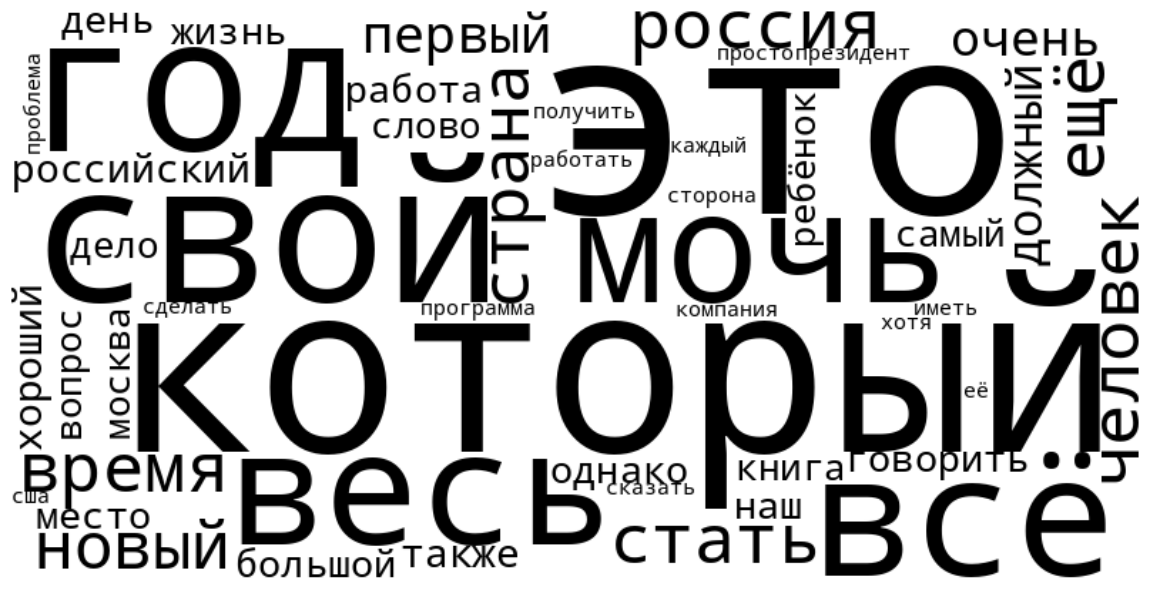

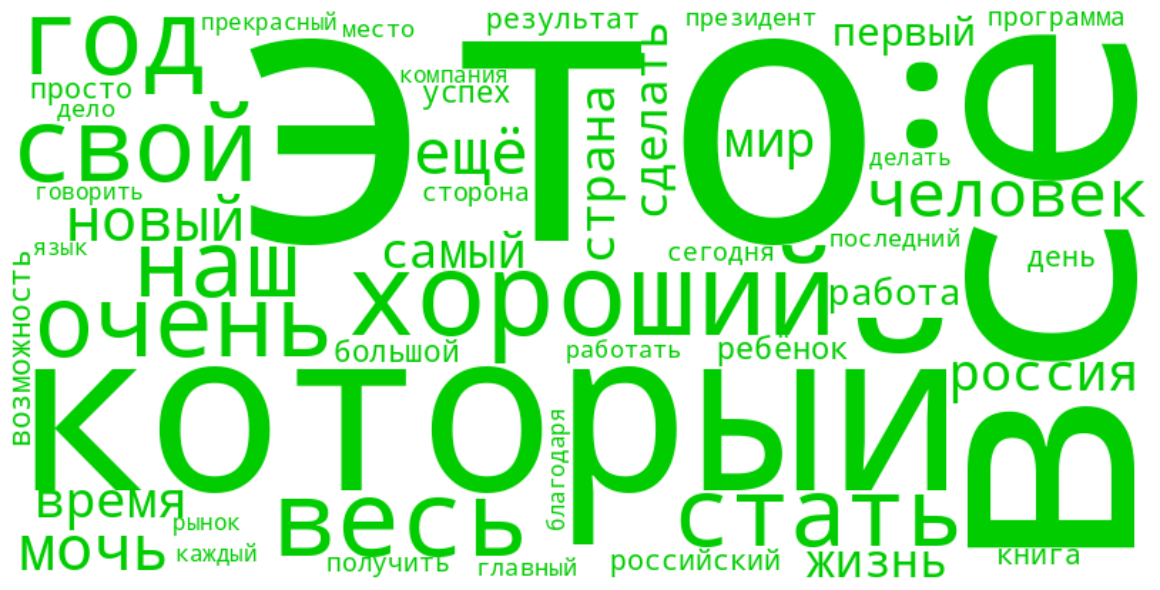

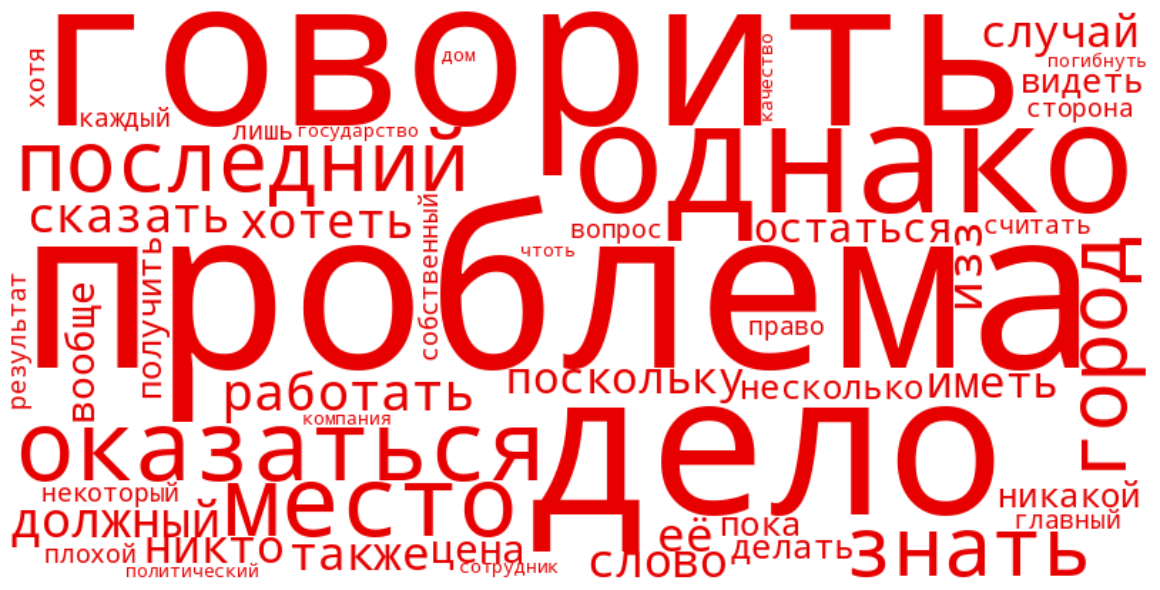

In [9]:
#Облака слов
!pip install pymorphy3 wordcloud -q

import pandas as pd
import re
import os
import pymorphy3
import nltk
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('stopwords', quiet=True)
stop_words_ru = set(nltk.corpus.stopwords.words('russian'))

extra_stopwords_negative = {'москва', 'война', 'власть', 'женщина', 'президент'}

possible_names = ['opensentimentcorpus-final-by-majority.csv', 'opensentimentcorpus-final-by-majority']
df = None
for name in possible_names:
    if os.path.exists(name):
        df = pd.read_csv(name)
        print(f"Loaded {name}, rows: {len(df)}")
        break
if df is None:
    print("File not found, creating demo dataset.")
    df = pd.DataFrame({
        'Sentence': ["этот товар очень хороший", "я не рекомендую этот продукт"],
        'Sentiment': ['positive', 'negative']
    })

df_work = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё ]', '', text)
    text = ' '.join(text.split())
    return text

df_work['clean_text'] = df_work['Sentence'].apply(clean_text)

morph = pymorphy3.MorphAnalyzer()
def lemmatize_text(text):
    words = text.split()
    lemmas = []
    for w in words:
        parsed = morph.parse(w)[0]
        lemmas.append(parsed.normal_form)
    return ' '.join(lemmas)

df_work['lemmas'] = df_work['clean_text'].apply(lemmatize_text)

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words_ru])

df_work['no_stopwords'] = df_work['lemmas'].apply(remove_stopwords)

all_words_clean = ' '.join(df_work['no_stopwords']).split()
word_counts_clean = Counter(all_words_clean)
top10_clean = word_counts_clean.most_common(10)

print("TOP-10 AFTER STOPWORDS REMOVAL:")
for w,c in top10_clean:
    print(f"{w}: {c}")

if top10_clean:
    words, counts = zip(*top10_clean)
    plt.figure(figsize=(10,5))
    plt.bar(words, counts, color='coral')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def black_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(0, 0%, 0%)"
def green_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(120, 100%, 40%)"
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(0, 100%, 45%)"

all_text = ' '.join(df_work['no_stopwords'])
wc_all = WordCloud(width=800, height=400, max_words=50, background_color='white',
                   color_func=black_color_func).generate(all_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

pos_texts = df_work[df_work['Sentiment'] == 'positive']['no_stopwords']
if len(pos_texts) > 0:
    pos_text = ' '.join(pos_texts)
    wc_pos = WordCloud(width=800, height=400, max_words=50, background_color='white',
                       color_func=green_color_func).generate(pos_text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc_pos, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    pos_words_freq = Counter(pos_text.split())
    top_positive_words = set([w for w, _ in pos_words_freq.most_common(30)])
else:
    top_positive_words = set()

neg_texts = df_work[df_work['Sentiment'] == 'negative']['no_stopwords']
if len(neg_texts) > 0:
    neg_text = ' '.join(neg_texts)
    neg_stopwords = stop_words_ru.union(top_positive_words).union(extra_stopwords_negative)
    wc_neg = WordCloud(width=800, height=400, max_words=50, background_color='white',
                       color_func=red_color_func, stopwords=neg_stopwords).generate(neg_text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Нет текстов с меткой 'negative'.")

In [ ]:
#TF-IDF
!pip install pymorphy3 -q

import pandas as pd
import re
import os
import pymorphy3
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords', quiet=True)
stop_words_ru = set(nltk.corpus.stopwords.words('russian'))

possible_names = ['opensentimentcorpus-final-by-majority.csv', 'opensentimentcorpus-final-by-majority']
df = None
for name in possible_names:
    if os.path.exists(name):
        df = pd.read_csv(name)
        print(f"Загружен: {name}, строк: {len(df)}")
        break
if df is None:
    print("Файл не найден. Создаю демо-датасет.")
    df = pd.DataFrame({
        'Sentence': [
            "хороший товар",
            "плохой товар",
            "нейтральный отзыв"
        ]
    })

df_work = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё ]', '', text)
    text = ' '.join(text.split())
    return text

df_work['clean_text'] = df_work['Sentence'].apply(clean_text)

morph = pymorphy3.MorphAnalyzer()
def lemmatize_text(text):
    words = text.split()
    lemmas = []
    for w in words:
        parsed = morph.parse(w)[0]
        lemmas.append(parsed.normal_form)
    return ' '.join(lemmas)

df_work['lemmas'] = df_work['clean_text'].apply(lemmatize_text)

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words_ru])

df_work['no_stopwords'] = df_work['lemmas'].apply(remove_stopwords)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_work['no_stopwords'])
feature_names = vectorizer.get_feature_names_out()

print(f"РАЗМЕР СЛОВАРЯ (уникальных лемм): {len(feature_names)}")
print("\nПРИМЕР ВЕКТОРА ДЛЯ ПЕРВОГО ТЕКСТА (ненулевые элементы):")
first_vector = tfidf_matrix[0].toarray()[0]
non_zero = first_vector.nonzero()[0]
for idx in non_zero[:10]:
    print(f"  '{feature_names[idx]}' -> {first_vector[idx]:.4f}")

Загружен: opensentimentcorpus-final-by-majority.csv, строк: 5961
РАЗМЕР СЛОВАРЯ (уникальных лемм): 14281

ПРИМЕР ВЕКТОРА ДЛЯ ПЕРВОГО ТЕКСТА (ненулевые элементы):
  'будущее' -> 0.6461
  'прожить' -> 0.7633


In [ ]:
#Информационный поиск
!pip install pymorphy3 -q

import pandas as pd
import re
import os
import pymorphy3
import nltk
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords', quiet=True)
stop_words_ru = set(nltk.corpus.stopwords.words('russian'))

possible_names = ['opensentimentcorpus-final-by-majority.csv', 'opensentimentcorpus-final-by-majority']
df = None
for name in possible_names:
    if os.path.exists(name):
        df = pd.read_csv(name)
        print(f"Загружен: {name}, строк: {len(df)}")
        break
if df is None:
    print("Файл не найден. Создаю демо-датасет.")
    df = pd.DataFrame({
        'Sentence': [
            "Отличный товар, рекомендую",
            "Ужасное качество, не покупайте",
            "Нейтральный отзыв, ничего особенного"
        ]
    })

df_work = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё ]', '', text)
    text = ' '.join(text.split())
    return text

def lemmatize_text(text):
    words = text.split()
    lemmas = []
    for w in words:
        parsed = morph.parse(w)[0]
        lemmas.append(parsed.normal_form)
    return ' '.join(lemmas)

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words_ru])

df_work['clean_text'] = df_work['Sentence'].apply(clean_text)

morph = pymorphy3.MorphAnalyzer()
df_work['lemmas'] = df_work['clean_text'].apply(lemmatize_text)
df_work['no_stopwords'] = df_work['lemmas'].apply(remove_stopwords)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_work['no_stopwords'])

def search(query, top_n=3):
    q_clean = clean_text(query)
    q_lemmas = lemmatize_text(q_clean)
    q_vec = vectorizer.transform([q_lemmas])
    similarities = cosine_similarity(q_vec, tfidf_matrix)[0]
    top_indices = similarities.argsort()[-top_n:][::-1]
    results = []
    for idx in top_indices:
        results.append({
            'Текст': df_work.iloc[idx]['Sentence'],
            'Похожесть': similarities[idx]
        })
    return results

queries = ["хорошее качество", "ужасный товар не рекомендую", "нейтрально"]
for q in queries:
    print(f"\nЗАПРОС: '{q}'")
    res = search(q, top_n=3)
    for i, r in enumerate(res, 1):
        print(f"{i}. Похожесть = {r['Похожесть']:.4f}")
        print(f"   Текст: {r['Текст'][:500]}...")

Загружен: opensentimentcorpus-final-by-majority.csv, строк: 5961

ЗАПРОС: 'хорошее качество'
1. Похожесть = 0.3902
   Текст: К тому же цифровая техника становится всё лучше и лучше....
2. Похожесть = 0.3622
   Текст: Я разных лекторов видел: плохих, хороших, очень хороших......
3. Похожесть = 0.3536
   Текст: Русскому руководству должно быть ясно, что качество наших отношений находится в неразрывной связи с качеством русской демократии....

ЗАПРОС: 'ужасный товар не рекомендую'
1. Похожесть = 0.2809
   Текст: То есть мы подошли к ситуации выбора между ужасным и чудовищным....
2. Похожесть = 0.2517
   Текст: Самое ужасное – когда мама плачет, или когда у нее болит сердце....
3. Похожесть = 0.1998
   Текст: Что, мол, опыт не имеет никакого значения перед лицом этого ужасного чудовища под названием кинематограф…...

ЗАПРОС: 'нейтрально'
1. Похожесть = 0.0000
   Текст: Не будущее, а то, что прожили....
2. Похожесть = 0.0000
   Текст: В понедельник представитель генсека ООН сказал, что Пан 